In [1]:
from src.baseline_config import build_training_config
from src.phase2.config import (
    PHASE2_CONFIDENCE_ONLY_FRAMES_DIR,
    PHASE2_CONFIDENCE_ONLY_THRESHOLD,
    PHASE2_RUNS,
)
from src.phase2.experiment import (
    curate_phase2_kinf_dataset,
    ingest_phase2_confidence_only_dataset,
    ingest_phase2_dataset,
    phase2_confidence_only_csv_path,
    phase2_confidence_only_runs,
    print_phase2_confidence_only_summary,
    print_phase2_detection_summary,
    print_phase2_failure_summary,
    print_phase2_source_summary,
    print_phase2_summary,
    print_phase2_train_summary,
    run_phase2_confidence_only_experiments,
    run_phase2_experiments,
    show_phase2_confidence_only_plots,
    show_phase2_plots,
)
from utils.metrics import print_results_metrics_summary

TRAINING_CONFIG = build_training_config(architecture="vit_small")


In [2]:
print_phase2_source_summary()

histology
Adenoma                     1578
Sessile_serrated_adenoma     725
Hyperplastic                 334
Adenocarcinoma               101
total: 2738


In [ ]:
execute = False
if execute:
    ingestion_summary = ingest_phase2_dataset()
    ingestion_summary

Max candidates per histology: {'Adenoma': 1, 'Sessile_serrated_adenoma': 3, 'Hyperplastic': 5, 'Adenocarcinoma': 16}
Histology augmentation summary:
               histology  current_samples  max_added_per_sample  max_added_samples  estimated_final_samples
                 Adenoma             1578                     1               1578                     3156
Sessile_serrated_adenoma              725                     3               2175                     2900
            Hyperplastic              334                     5               1670                     2004
          Adenocarcinoma              101                    16               1616                     1717
Estimated totals: current_samples=2738, max_added_samples=7039, estimated_final_samples=9777


Procesando videos:   3%|▎         | 14/428 [01:22<40:50,  5.92s/video, pendientes=414 fallidos=4 anadidas[Adenoma:20 SSA:73 Hyperplastic:15 Adenocarcinoma:0]]


KeyboardInterrupt: 

In [ ]:
curation_summary = curate_phase2_kinf_dataset()
curation_summary

{'source_csv_path': 'C:\\Users\\luis\\Documents\\TFG - Data-Centric AI\\data\\phase2\\phase2_train.csv',
 'output_csv_path': 'C:\\Users\\luis\\Documents\\TFG - Data-Centric AI\\data\\phase2\\phase2_train_kinf.csv',
 'confidence_threshold': 0.4,
 'total_rows': 6319,
 'original_rows': 2738,
 'video_rows': 3581,
 'dropped_video_rows': 1659}

In [ ]:
print_phase2_train_summary()

histology
Adenoma                     2459
Sessile_serrated_adenoma    1926
Hyperplastic                1210
Adenocarcinoma               724
total: 6319


In [ ]:
print_phase2_detection_summary()

               histology  total_images  annotated_images  unannotated_images  mean_annotated_confidence
                   TOTAL          6319              5517                 802                     0.6092
          Adenocarcinoma           724               705                  19                     0.6311
                 Adenoma          2459              2013                 446                     0.6117
            Hyperplastic          1210              1101                 109                     0.6159
Sessile_serrated_adenoma          1926              1698                 228                     0.5930


In [ ]:
run_phase2_experiments(training_config=TRAINING_CONFIG, force_train=False)

Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\seed_1\best_baseline_model.pth


c:\Users\luis\Documents\TFG - Data-Centric AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\seed_2\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\seed_3\best_baseline_model.pth


Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\seed_4\best_baseline_model.pth


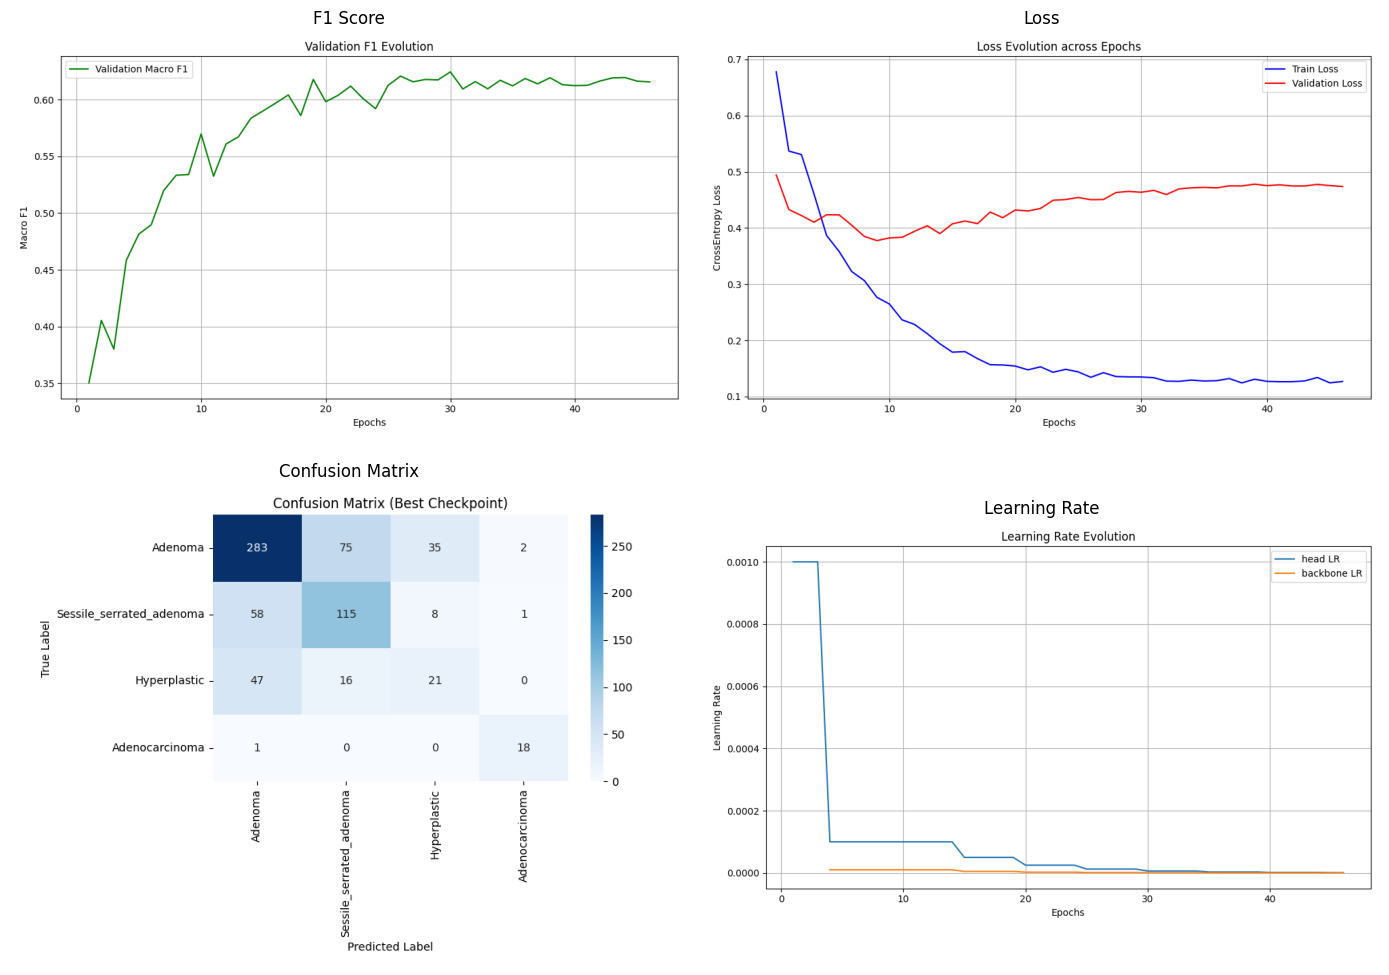

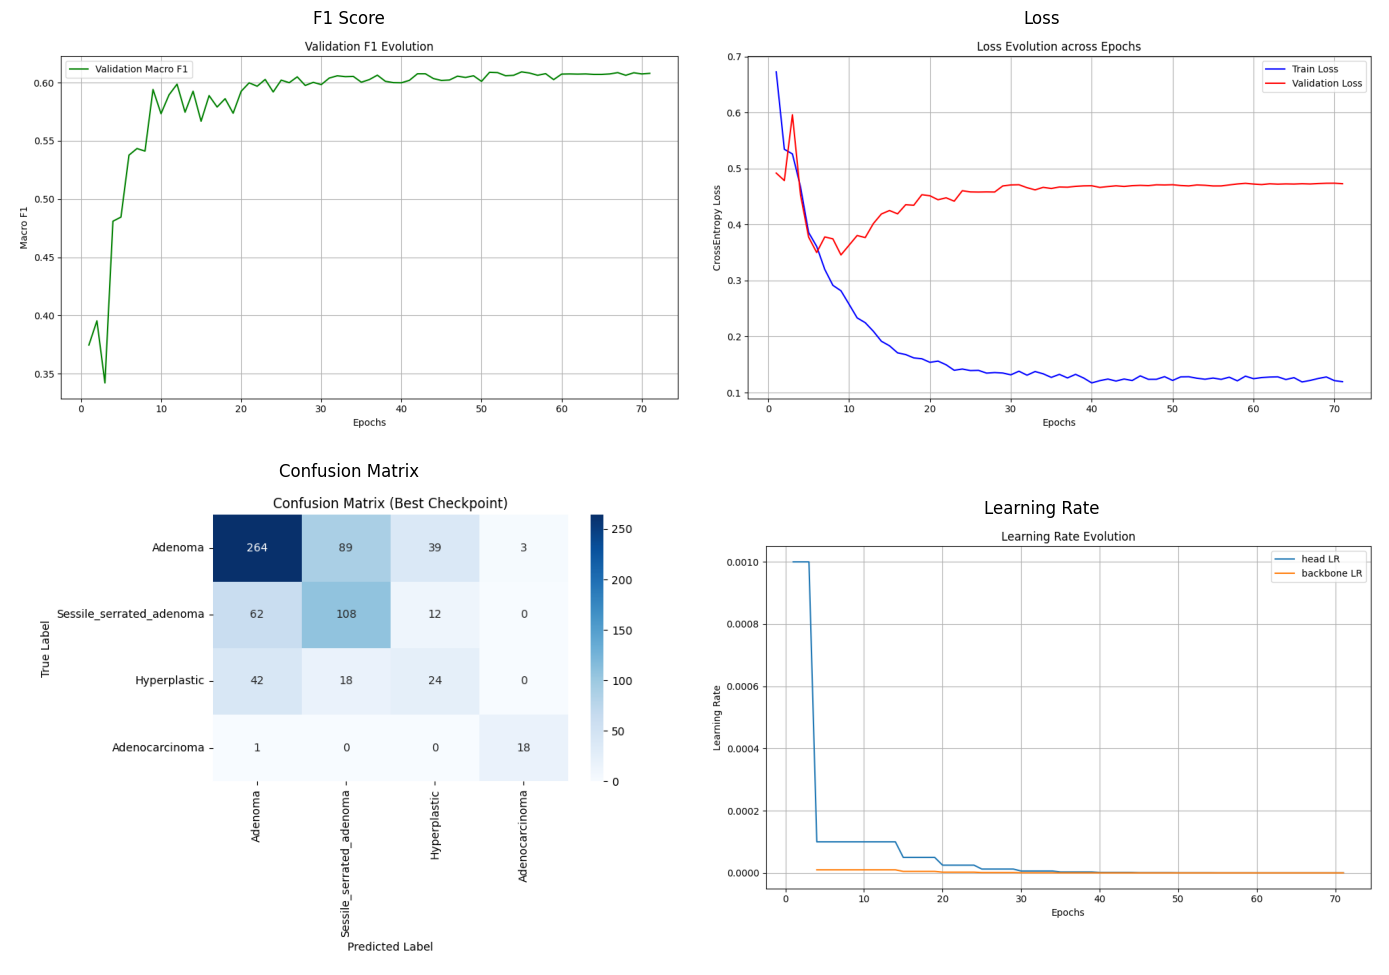

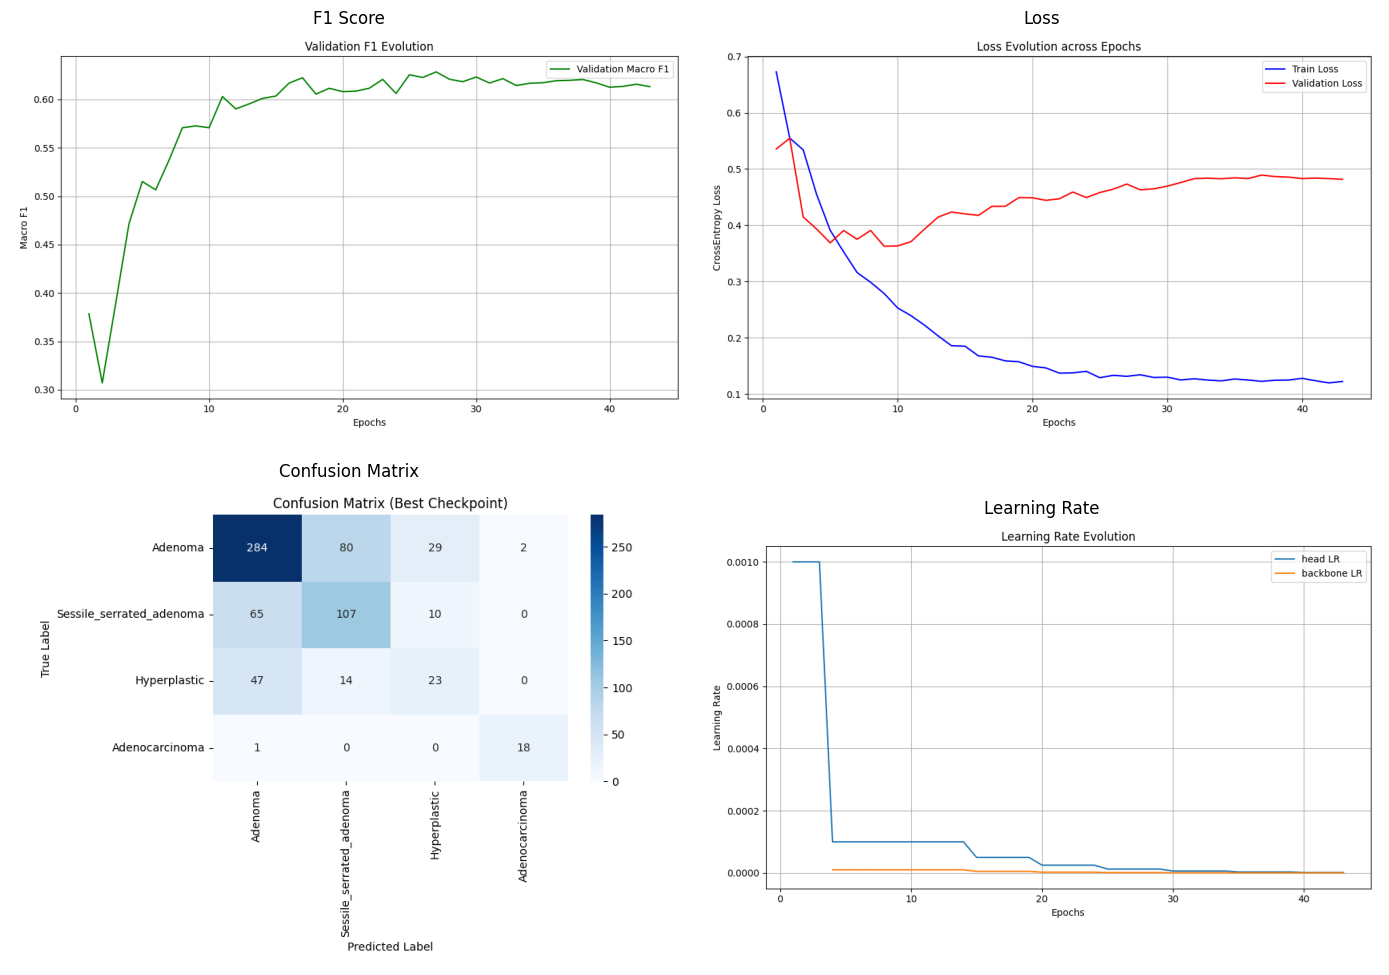

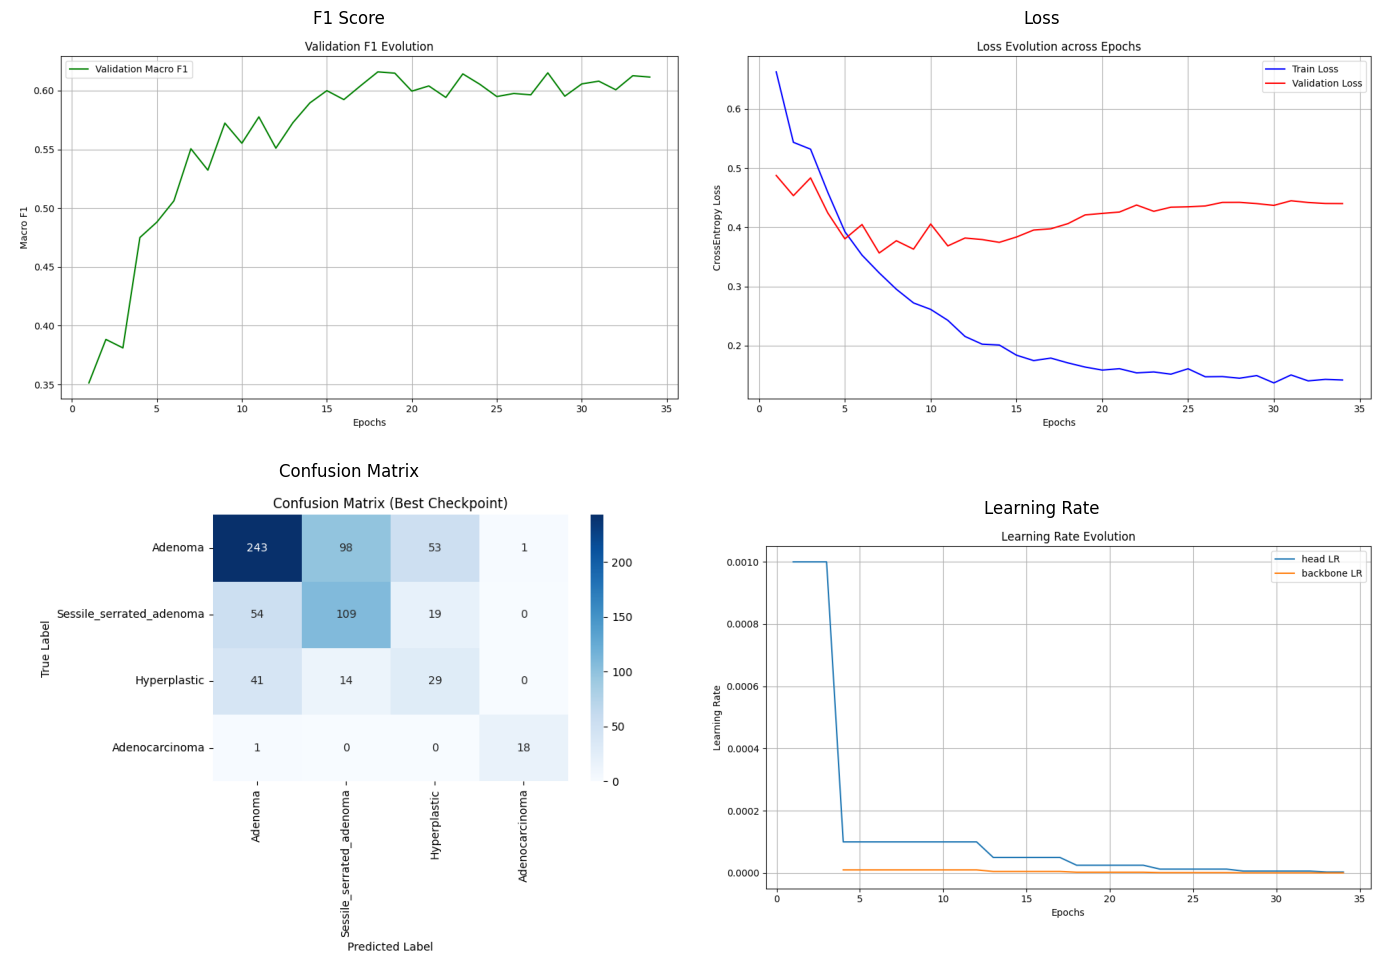

In [ ]:
show_phase2_plots(training_config=TRAINING_CONFIG)

In [ ]:
print_phase2_summary(training_config=TRAINING_CONFIG)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.6184 +/- 0.0256,0.3478 +/- 0.0266,0.6196 +/- 0.0087,0.6143 +/- 0.0129,0.6297 +/- 0.0056
1,Adenoma,0.6596 +/- 0.0196,0.3095 +/- 0.0300,0.6981 +/- 0.0275,0.7188 +/- 0.0059,0.6797 +/- 0.0489
2,Sessile_serrated_adenoma,0.7452 +/- 0.0180,0.3835 +/- 0.0359,0.5591 +/- 0.0237,0.5215 +/- 0.0296,0.6030 +/- 0.0197
3,Hyperplastic,0.8368 +/- 0.0170,0.2141 +/- 0.0166,0.3036 +/- 0.0144,0.3266 +/- 0.0345,0.2887 +/- 0.0405
4,Adenocarcinoma,0.9952 +/- 0.0014,0.9158 +/- 0.0228,0.9176 +/- 0.0226,0.8904 +/- 0.0430,0.9474 +/- 0.0000


In [ ]:
print_results_metrics_summary(
    results_dirs=[run["results_dir"] for run in PHASE2_RUNS],
    validation_csv_dir="test/external_test.csv",
    validation_img_dir="test/images_cropped",
    training_config=TRAINING_CONFIG,
    random_states=[run["random_state"] for run in PHASE2_RUNS],
)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.4554 +/- 0.0070,0.3071 +/- 0.0157,0.3695 +/- 0.0007,0.4566 +/- 0.0090,0.4646 +/- 0.0221
1,Adenoma,0.6649 +/- 0.0036,0.3171 +/- 0.0211,0.5483 +/- 0.0143,0.4540 +/- 0.0048,0.6925 +/- 0.0380
2,Sessile_serrated_adenoma,0.7600 +/- 0.0079,0.0742 +/- 0.0204,0.0575 +/- 0.0080,0.0305 +/- 0.0042,0.5000 +/- 0.0786
3,Hyperplastic,0.6692 +/- 0.0056,0.0589 +/- 0.0079,0.1775 +/- 0.0337,0.4003 +/- 0.0088,0.1152 +/- 0.0274
4,Adenocarcinoma,0.8168 +/- 0.0088,0.6187 +/- 0.0230,0.6947 +/- 0.0134,0.9415 +/- 0.0259,0.5505 +/- 0.0088


In [2]:
execute = False
if execute:
    ingestion_summary = ingest_phase2_confidence_only_dataset(
        confidence_threshold=PHASE2_CONFIDENCE_ONLY_THRESHOLD,
        frames_dir=PHASE2_CONFIDENCE_ONLY_FRAMES_DIR,
    )
    ingestion_summary

In [3]:
CONFIDENCE_ONLY_TRAIN_CSV = phase2_confidence_only_csv_path(
    PHASE2_CONFIDENCE_ONLY_THRESHOLD
)
print_phase2_failure_summary(output_csv_path=CONFIDENCE_ONLY_TRAIN_CSV)


,video_key,status,error_type,message,traceback_tail
0,4101414::20241213_102820_R2_34b16ba5d8336515.mp4,failed,FileNotFoundError,Could not open video: c:\Users\luis\Documents\...,"File ""c:\Users\luis\Documents\TFG - Data-Cen..."
1,4899931::20241213_114956_R6_1e85f910cd7832f5.mp4,failed,FileNotFoundError,Could not open video: c:\Users\luis\Documents\...,"File ""c:\Users\luis\Documents\TFG - Data-Cen..."
2,70472575::20241213_133837_R6_ca03b1e440d5b383.mp4,failed,RuntimeError,download failed,"Traceback (most recent call last):\n File ""c:..."
3,70612836::20241213_151536_R4_51a2091b8a5366be.mp4,failed,FileNotFoundError,Could not open video: c:\Users\luis\Documents\...,"File ""c:\Users\luis\Documents\TFG - Data-Cen..."


In [4]:
print_phase2_train_summary(train_csv=CONFIDENCE_ONLY_TRAIN_CSV)


histology
Adenoma                     8313
Sessile_serrated_adenoma    3047
Hyperplastic                1421
Adenocarcinoma               515
total: 13296


In [5]:
print_phase2_detection_summary(train_csv=CONFIDENCE_ONLY_TRAIN_CSV)


               histology  total_images  annotated_images  unannotated_images  mean_annotated_confidence
                   TOTAL         13296             12494                 802                     0.7240
          Adenocarcinoma           515               496                  19                     0.6878
                 Adenoma          8313              7867                 446                     0.7414
            Hyperplastic          1421              1312                 109                     0.6921
Sessile_serrated_adenoma          3047              2819                 228                     0.6969


In [6]:
run_phase2_confidence_only_experiments(
    training_config=TRAINING_CONFIG,
    force_train=False,
    confidence_threshold=PHASE2_CONFIDENCE_ONLY_THRESHOLD,
    train_images_dir=PHASE2_CONFIDENCE_ONLY_FRAMES_DIR,
)


Loss weights: {'Adenoma': 0.297, 'Sessile_serrated_adenoma': 0.5995, 'Hyperplastic': 1.0226, 'Adenocarcinoma': 2.0809}


c:\Users\luis\Documents\TFG - Data-Centric AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\conf060\seed_1


Training Progress:  47%|████▋     | 47/100 [1:35:06<1:47:14, 121.41s/epoch, Stage=full_network, Train Loss=0.0524, Val Loss=0.5321, Val Macro F1=0.5941, Selection Score=-0.5941, Best Epoch=32, LR=1.0e-07/3.9e-07]       


Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 42. Selected checkpoint macro-F1: 0.6213 with validation loss 0.5353 and validation score -0.6213 at epoch 32.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\conf060\seed_1'.
Loss weights: {'Adenoma': 0.297, 'Sessile_serrated_adenoma': 0.5995, 'Hyperplastic': 1.0226, 'Adenocarcinoma': 2.0809}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\conf060\seed_2


...

Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 123. Selected checkpoint macro-F1: 0.6188 with validation loss 0.5119 and validation score -0.6188 at epoch 30.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\conf060\seed_2'.
Loss weights: {'Adenoma': 0.297, 'Sessile_serrated_adenoma': 0.5995, 'Hyperplastic': 1.0226, 'Adenocarcinoma': 2.0809}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\conf060\seed_3


Training Progress:  39%|███▉      | 39/100 [1:18:25<2:02:39, 120.65s/epoch, Stage=full_network, Train Loss=0.0543, Val Loss=0.5035, Val Macro F1=0.6083, Selection Score=-0.6083, Best Epoch=24, LR=1.0e-07/7.8e-07]     


Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 456. Selected checkpoint macro-F1: 0.6138 with validation loss 0.4770 and validation score -0.6138 at epoch 24.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\conf060\seed_3'.
Loss weights: {'Adenoma': 0.297, 'Sessile_serrated_adenoma': 0.5995, 'Hyperplastic': 1.0226, 'Adenocarcinoma': 2.0809}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\conf060\seed_4


Training Progress:  45%|████▌     | 45/100 [1:30:32<1:50:39, 120.71s/epoch, Stage=full_network, Train Loss=0.0596, Val Loss=0.4804, Val Macro F1=0.6134, Selection Score=-0.6134, Best Epoch=30, LR=1.0e-07/3.9e-07]     


Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 789. Selected checkpoint macro-F1: 0.6177 with validation loss 0.4775 and validation score -0.6177 at epoch 30.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\conf060\seed_4'.


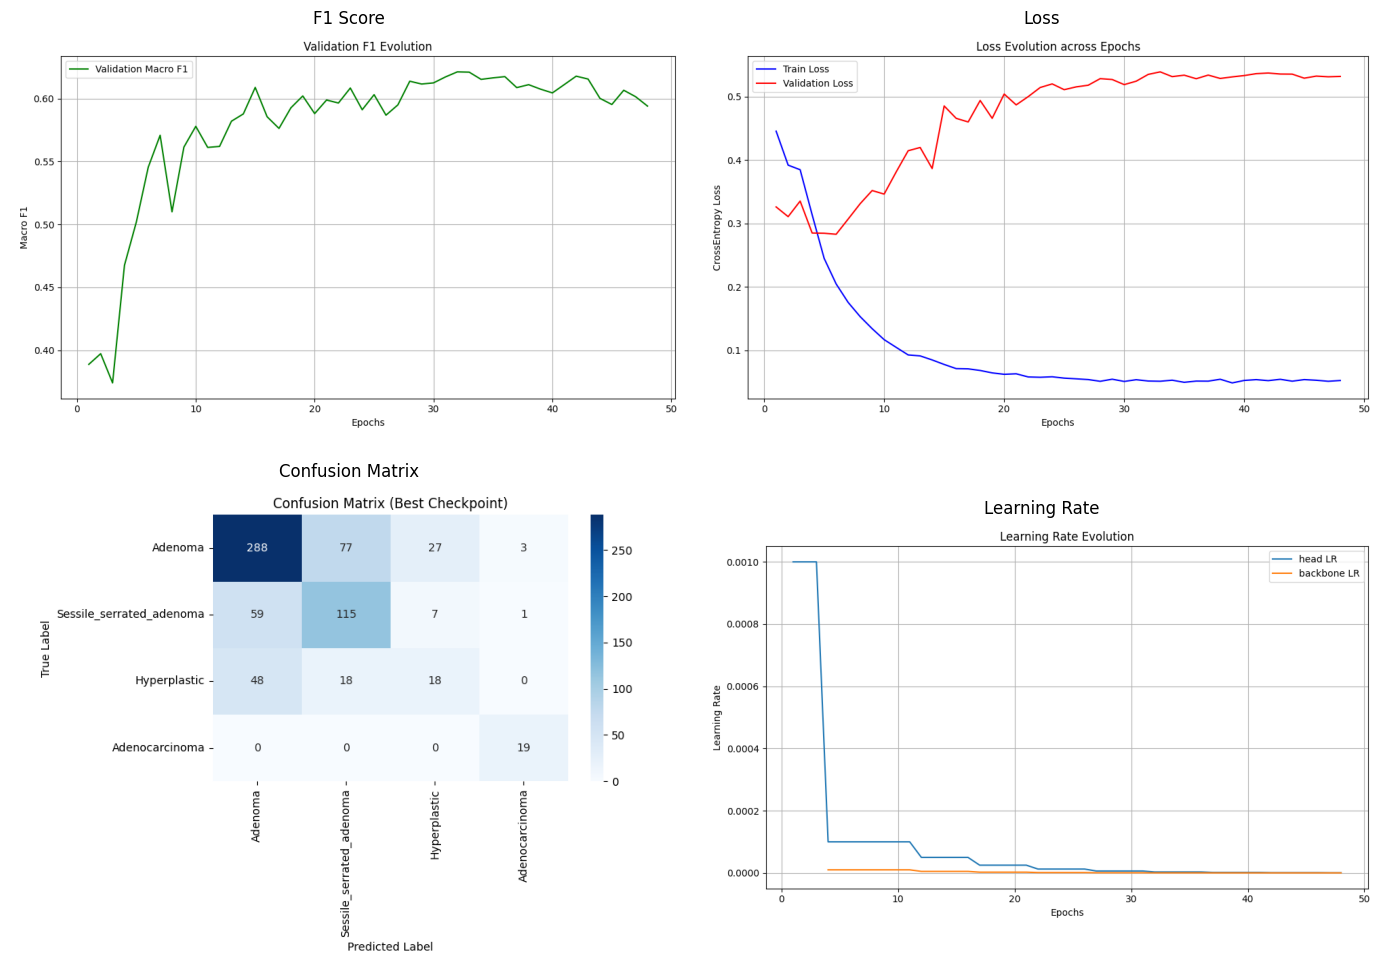

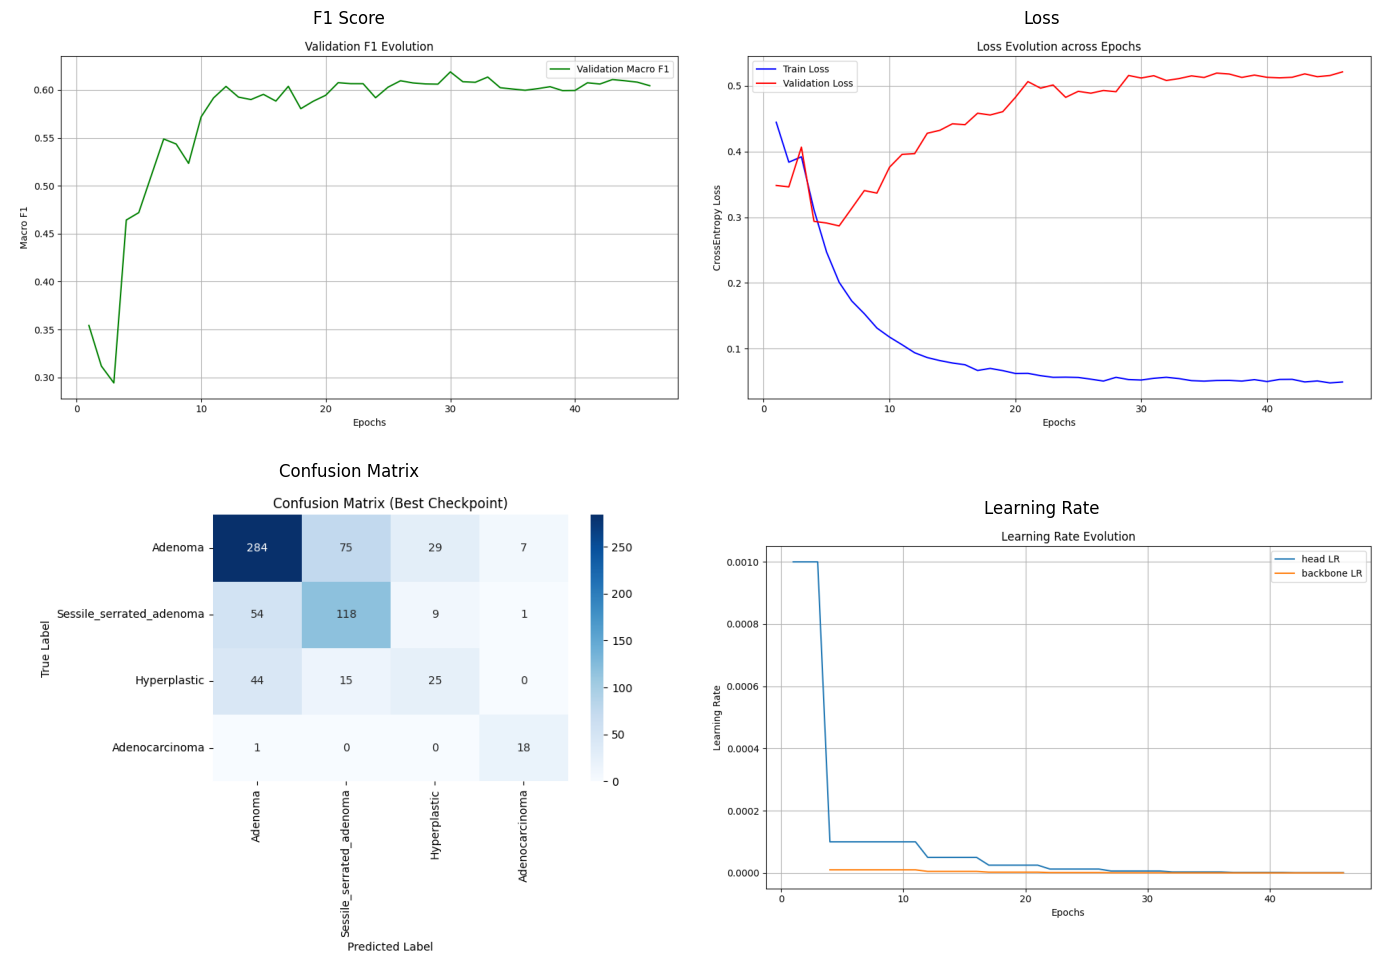

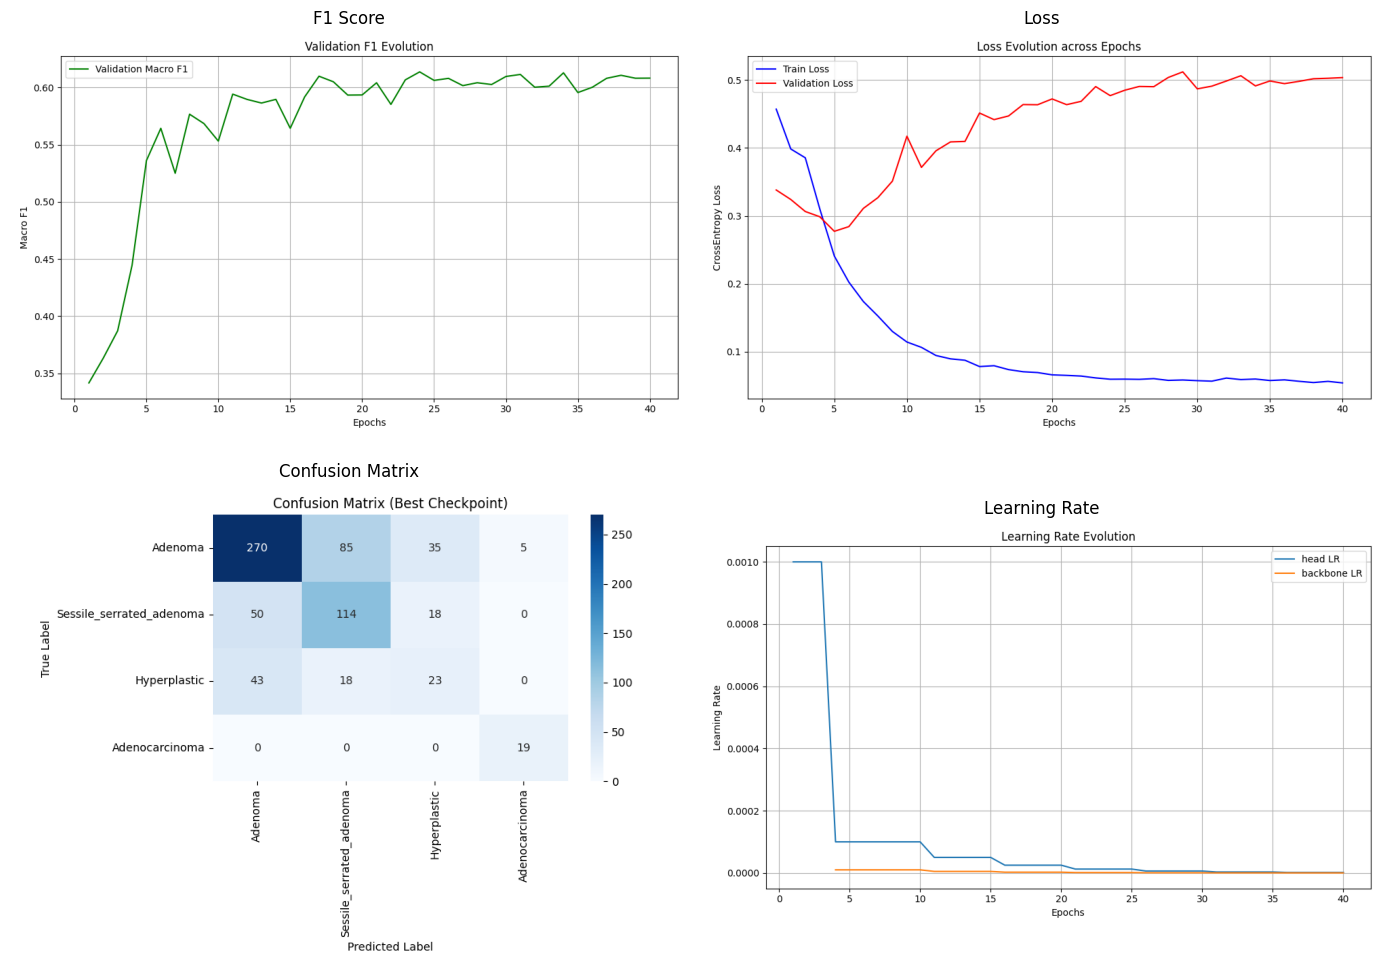

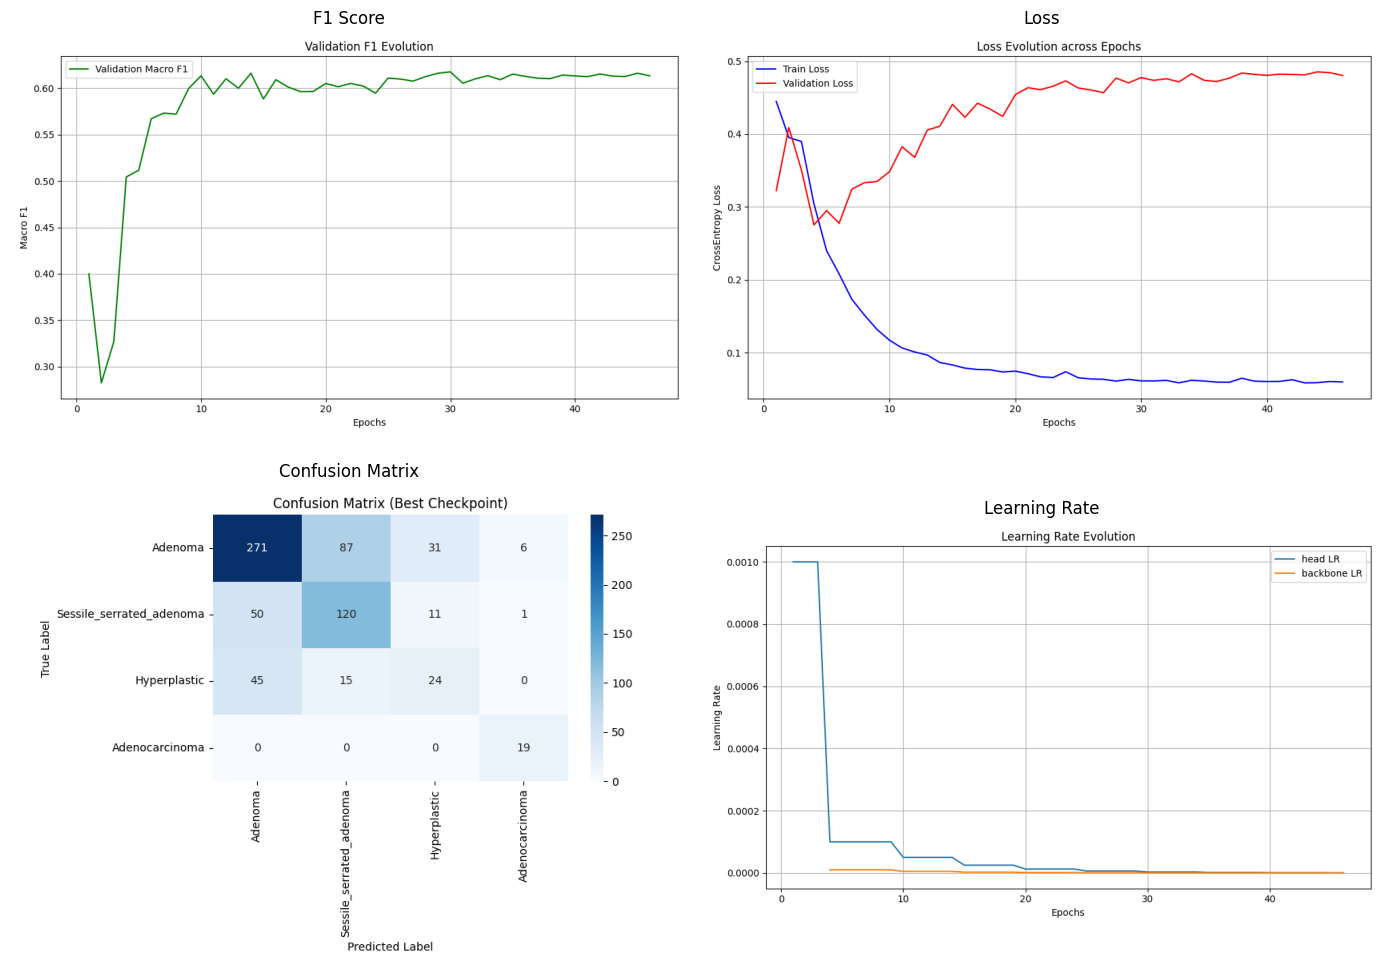

In [7]:
show_phase2_confidence_only_plots(
    training_config=TRAINING_CONFIG,
    confidence_threshold=PHASE2_CONFIDENCE_ONLY_THRESHOLD,
)


In [8]:
print_phase2_confidence_only_summary(
    training_config=TRAINING_CONFIG,
    confidence_threshold=PHASE2_CONFIDENCE_ONLY_THRESHOLD,
)


,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.6415 +/- 0.0120,0.3848 +/- 0.0146,0.6179 +/- 0.0032,0.5991 +/- 0.0095,0.6502 +/- 0.0064
1,Adenoma,0.6835 +/- 0.0060,0.3565 +/- 0.0091,0.7210 +/- 0.0100,0.7387 +/- 0.0066,0.7044 +/- 0.0231
2,Sessile_serrated_adenoma,0.7607 +/- 0.0103,0.4249 +/- 0.0209,0.5893 +/- 0.0141,0.5452 +/- 0.0174,0.6415 +/- 0.0151
3,Hyperplastic,0.8482 +/- 0.0110,0.2231 +/- 0.0354,0.3031 +/- 0.0335,0.3523 +/- 0.0392,0.2679 +/- 0.0370
4,Adenocarcinoma,0.9908 +/- 0.0033,0.8617 +/- 0.0450,0.8582 +/- 0.0462,0.7602 +/- 0.0600,0.9868 +/- 0.0263


In [9]:
CONFIDENCE_ONLY_RUNS = phase2_confidence_only_runs(
    PHASE2_CONFIDENCE_ONLY_THRESHOLD
)
print_results_metrics_summary(
    results_dirs=[run["results_dir"] for run in CONFIDENCE_ONLY_RUNS],
    validation_csv_dir="test/external_test.csv",
    validation_img_dir="test/images_cropped",
    training_config=TRAINING_CONFIG,
    random_states=[run["random_state"] for run in CONFIDENCE_ONLY_RUNS],
)


,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.4389 +/- 0.0104,0.2894 +/- 0.0114,0.3513 +/- 0.0106,0.4565 +/- 0.0166,0.4946 +/- 0.0061
1,Adenoma,0.6242 +/- 0.0170,0.2837 +/- 0.0154,0.5337 +/- 0.0078,0.4205 +/- 0.0123,0.7313 +/- 0.0225
2,Sessile_serrated_adenoma,0.7785 +/- 0.0105,0.1284 +/- 0.0053,0.0812 +/- 0.0037,0.0432 +/- 0.0021,0.6667 +/- 0.0000
3,Hyperplastic,0.6765 +/- 0.0072,0.0574 +/- 0.0343,0.1403 +/- 0.0271,0.4145 +/- 0.0634,0.0846 +/- 0.0177
4,Adenocarcinoma,0.7987 +/- 0.0140,0.5829 +/- 0.0289,0.6502 +/- 0.0336,0.9479 +/- 0.0146,0.4957 +/- 0.0394
